<a href="https://colab.research.google.com/github/nicolagherardi/AI_course_test/blob/main/Assignment_4_v9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests

def invia_notifica_telegram(testo):
    token = "8673479885:AAGJHwTcW2T37qUx6SDFUwMaWfuGq0xNLtw"
    chat_id = "1350032346"
    url = f"https://api.telegram.org/bot{token}/sendMessage"
    payload = {"chat_id": chat_id, "text": testo}
    requests.post(url, json=payload)

# **Neural Network**
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [2]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
#df = pd.read_csv('Exercise7BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


How many rows and columns does the dataset contain?

In [3]:
df.shape

(17379, 17)

Are any of the columns missing values?

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target = 'cnt'
df["hr_workingday"]=df['hr'] * df["workingday"]
df["hr_holiday"]=df['hr'] * df["holiday"]
df["temp_season"]=df['temp'] * df["season"]
df["weathersit_hum"]=df['weathersit'] * df["hum"]

features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season','yr',
    'hr_workingday','hr_holiday','temp_season','weathersit_hum'
]

X = df[features].copy()
y = df[target].astype(float)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [6]:
# just for context
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': np.float64(139.16676798397307), 'LR_MAE': np.float64(104.80129131901948), 'LR_R2': 0.3883739861984008}


## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [7]:
#pip install tensorflow

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# # Create a Sequential model, which is a linear stack of layers.
# model = Sequential()
# # Add a Dense layer with 32 units, ReLU activation, and an input dimension of 11.
# model.add(Dense(32, activation='relu', input_dim=X_train_scaled.shape[1]))
# # Add another Dense layer with 64 units and ReLU activation.
# model.add(Dense(64, activation='relu'))
# # Add a final Dense layer with 1 unit (typically used for regression tasks).
# model.add(Dense(1))
# # Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# # and MAE metric to be used during training.
# model.compile(optimizer='adam', loss='mae', metrics=['mae'])
# # Display a summary of the model architecture, including the number of parameters.
# model.summary()

## Training and prediction
We split the dataset into a training and a test dataset. Then, we fit the neural network model with the training dataset and predict the values for the test dataset.

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# # Fit the model to the training data, specifying validation split, epochs, and batch size.
# hist = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32)
# # Set the style of the plots using Seaborn.
# sns.set()
# # Extract the training and validation Mean Absolute Error (MAE) from the training history.
# err = hist.history['mae']
# val_err = hist.history['val_mae']
# # Define the number of epochs.
# epochs = range(1, len(err) + 1)
# # Plot the Training MAE and Validation MAE over epochs.
# plt.plot(epochs, err, '-', label='Training MAE')
# plt.plot(epochs, val_err, ':', label='Validation MAE')
# plt.title('Training and Validation MAE')
# plt.xlabel('Epoch')
# plt.ylabel('Mean Absolute Error')
# plt.legend(loc='upper right')
# plt.plot()
# # Use the trained model to predict on the test data.
# y_pred = model.predict(X_test_scaled)

## Evaluate the model
You can evaluate the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), or R-squared (R2).

In [10]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# # Calculate the Mean Absolute Error (MAE) between the true and predicted values.
# mae_nn = mean_absolute_error(y_test, y_pred)
# # Calculate the Root Mean Squared Error (RMSE) between the true and predicted values.
# mse_nn = mean_squared_error(y_test, y_pred)
# rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred))
# # Calculate the R-squared (R2) score, a measure of how well the model explains the variance in the data.
# r2_nn = r2_score(y_test, y_pred)
# # Print the calculated metrics.
# print(f"Mean Absolute Error of NN: {mae_nn}")
# print(f"Root Mean Squared Error of NN: {rmse_nn}")
# print(f"R-squared of NN: {r2_nn}")

## Compare Metrics (optional)
we compare the performance of NN with baseline linear regression.

In [11]:
# import pandas as pd
# results = pd.DataFrame([
#     {'Model': 'Linear Regression', 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr},
#     {'Model': 'Neural Net', 'RMSE': rmse_nn, 'MAE': mae_nn, 'R2': r2_nn},
# ])
# results

In [12]:
# # Bar chart of RMSE
# plt.figure()
# plt.bar(results['Model'], results['RMSE'])
# plt.ylabel('RMSE')
# plt.title('RMSE Comparison')
# plt.show()

# **Task 2: Practical NN training techniques**
The task will illustrate some useful NN training techniques, including saving and loading the trained model, using the callback function to save the best model, and adding dropout layers.


In [13]:
from json import load
import pandas as pd
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model

# #-------------------------------------------------data preprocessing------------------------------------------------------------------


# #-------------------------------------------------network construction-----------------------------------------------------------------

# #************************************************Here you can choose to add the dropout layer or not***************************
# #
# # def construct_network_model():
# #   # Create a Sequential model, which is a linear stack of layers.
# #   model = Sequential()
# #
# #   # Add a Dense layer with 32 units, ReLU activation, and an input dimension of 4.
# #   model.add(Dense(32, activation='relu', input_dim=4))
# #
# #   # # Add a Dropout layer with a dropout rate of 0.5.
# #   # model.add(Dropout(0.5))
# #
# #   # Add another Dense layer with 64 units and ReLU activation.
# #   model.add(Dense(64, activation='relu'))
# #
# #   # # Add another Dropout layer with a dropout rate of 0.5.
# #   # model.add(Dropout(0.5))
# #
# #   # Add a final Dense layer with 1 unit (typically used for regression tasks).
# #   model.add(Dense(1))
# #   return model
# #
# # model=construct_network_model()
# # # Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# # # and MAE metric to be used during training.
# # model.compile(optimizer='adam', loss='mae', metrics=['mae'])
# #************************************************Here you can choose to add the dropout layer or not*****************

# #-------------------------------------------------model train------------------------------------------------------------------
# # use the callback function to early stop, learning rate ajusting, save the best model
# # Create an EarlyStopping callback to monitor the validation mean absolute error (val_mae).
# # It will stop training if val_mae doesn't improve for 5 consecutive epochs and restores the best weights.
# early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

# # Create a ReduceLROnPlateau callback to monitor val_mae.
# # It reduces the learning rate by a factor of 0.5 if val_mae doesn't improve for 3 consecutive epochs.
# reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)

# # Define the file path where the best model will be saved.
# filepath = "weights.best.keras"

# # Create a ModelCheckpoint callback to monitor the validation mae (val_mae).
# # The callback will save thhe model's weights only if the validation mae improves.
# checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# # Train the model using the fit method.
# hist_2 = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=0)


# #-------------------------------------------------model evaluation--------------------------------------------------------------------

# # Set the style of the plots using Seaborn.
# sns.set()

# # Extract the training and validation Mean Absolute Error (MAE) from the training history.
# err = hist_2.history['mae']
# val_err = hist_2.history['val_mae']

# # Define the number of epochs.
# epochs = range(1, len(err) + 1)

# # Plot the Training MAE and Validation MAE over epochs.
# plt.plot(epochs, err, '-', label='Training MAE')
# plt.plot(epochs, val_err, ':', label='Validation MAE')
# plt.title('Training and Validation MAE')
# plt.xlabel('Epoch')
# plt.ylabel('Mean Absolute Error')
# plt.legend(loc='upper right')
# plt.plot()

# # Use the trained model to predict on the test data.
# y_pred = model.predict(X_test_scaled)

# # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print('--------------------------------------'+'this is result of the trained model'+"---------------------------------------------")
# # Print the calculated metrics.
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")
# print(f"R-squared: {r2}")

# #-------------------------------------------------load model and evaluation--------------------------------------------------------------------
# if not filepath =="":
#   # Load a pre-trained model from the specified file path.
#   model = load_model(filepath)

#   # Use the loaded model to predict on the test data.
#   y_pred = model.predict(X_test_scaled)

#   # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
#   mae = mean_absolute_error(y_test, y_pred)
#   mse = mean_squared_error(y_test, y_pred)
#   r2 = r2_score(y_test, y_pred)

#   print('--------------------------------------'+'this is result of the model loaded from the local path'+"---------------------------------------------")

#   # Print the calculated metrics.
#   print(f"Mean Absolute Error: {mae}")
#   print(f"Mean Squared Error: {mse}")
#   print(f"R-squared: {r2}")



#   # Create a scatter plot to visualize the relationship
#   plt.figure(figsize=(8, 6))
#   plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

#   # Add labels and title
#   plt.xlabel("Actual Values")
#   plt.ylabel("Predicted Values")
#   plt.title("Actual vs. Predicted Values")

#   # Add a diagonal line for reference (perfect predictions)
#   plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

#   # Show the plot
#   plt.show()


# **Task 3: Compare the results with a linear regression model**
The task involves comparing the results obtained from the neural network with those from the linear regression model, and we should analyze the reasons behind any differences in the outcomes.

In [14]:
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

# # Set the style of the plots using seaborn.
# sns.set()

# # Use the trained model to predict on the test data.
# y_pred = model.predict(X_test_scaled)

# # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# r2 = r2_score(y_test, y_pred)

# print('--------------------------------------'+'this is result of the neural network model'+"---------------------------------------------")
# # Print the evaluation metrics.
# print(f"Mean Absolute Error: {mae}")
# print(f"Root Mean Squared Error: {rmse}")
# print(f"R-squared: {r2}")


# # Create a Linear Regression model
# model_linear = LinearRegression()
# model_linear.fit(X_train_scaled, y_train)
# y_pred_linear = model_linear.predict(X_test_scaled)

# mae_linear = mean_absolute_error(y_test, y_pred_linear)
# rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
# r2_linear = r2_score(y_test, y_pred_linear)

# print('--------------------------------------'+'this is result of the linear regression model'+"---------------------------------------------")
# print(f"Mean Absolute Error of linear model: {mae_linear}")
# print(f"Root Mean Squared Error of linear model: {rmse_linear}")
# print(f"R-squared of linear model: {r2_linear}")

# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

In [18]:
#!pip install -U scikeras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

2 layers model

In [19]:
param_grid_2 = {
    'model__neurons_1': [32, 64, 128], # Number of neurons in the first hidden layer
    'model__learning_rate': [2e-3, 2e-1, 2]
}

In [20]:
def create_2layers_model(neurons_1=64, learning_rate=2e-5):
    model_2 = Sequential()
    model_2.add(Dense(neurons_1, activation='relu', input_dim=X_train_scaled.shape[1]))
    model_2.add(Dropout(0.5))
    model_2.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)
    model_2.compile(optimizer=optimizer, loss='mae', metrics=['mae'])
    model_2.summary()
    return model_2

In [21]:
model_2_wrapper = KerasRegressor(model=create_2layers_model, epochs=20, batch_size=32, verbose=0)

In [22]:
grid_2 = GridSearchCV(estimator=model_2_wrapper, param_grid=param_grid_2, cv=3, scoring='neg_mean_absolute_error', n_jobs=1)

In [23]:
grid_2_result = grid_2.fit(X_train_scaled, y_train)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

...

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
best_params_2 = grid_2_result.best_params_

print(f"MAE: {grid_2_result.best_score_:.4f}")
print(f"Best parameters: {best_params_2}")

MAE: -84.8673
Best parameters: {'model__learning_rate': 0.2, 'model__neurons_1': 64}


In [25]:
model_2 = create_2layers_model(
    neurons_1=best_params_2['model__neurons_1'],
    learning_rate=best_params_2['model__learning_rate']
)

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)
filepath = "model_2.best.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# Train the model using the fit method
hist_2 = model_2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=1)


Epoch 1/200
340/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 112.2754 - mae: 112.2754
Epoch 1: val_mae improved from None to 92.57999, saving model to model_2.best.keras

Epoch 1: finished saving model to model_2.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 108.2120 - mae: 108.2120 - val_loss: 92.5800 - val_mae: 92.5800 - learning_rate: 0.2000
Epoch 2/200
329/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103.2123 - mae: 103.2123
Epoch 2: val_mae improved from 92.57999 to 91.60503, saving model to model_2.best.keras

Epoch 2: finished saving model to model_2.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 101.7689 - mae: 101.7689 - val_loss: 91.6050 - val_mae: 91.6050 - learning_rate: 0.2000
Epoch 3/200
331/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 100.3025 - mae: 100.3025
Epoch 3: val_mae improved from 91.60503 to 89.99726, saving model to model_2.best.keras

Epoch 3: finished saving model to model_2.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - los

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


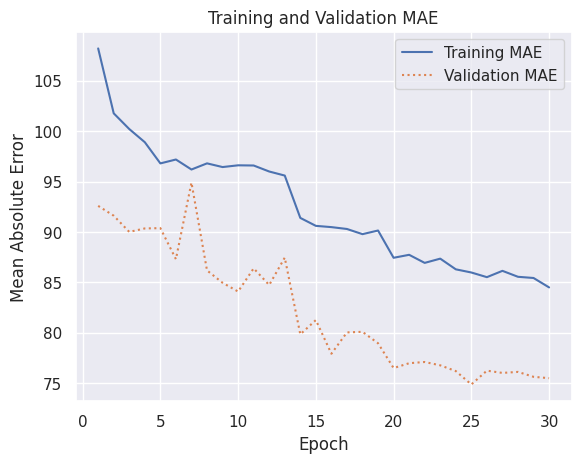

In [27]:
# Set the style of the plots using Seaborn.
sns.set()
# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']
# Define the number of epochs.
epochs = range(1, len(err) + 1)
# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()
# Use the trained model to predict on the test data.
y_pred_nn_2 = model_2.predict(X_test_scaled)

3 layers model

In [28]:
param_grid_3 = {
    'model__neurons_1': [32, 64], # Number of neurons in the first hidden layer
    'model__neurons_2': [32, 64], # Number of neurons in the second hidden layer
    'model__learning_rate': [2e-5, 2e-3, 2e-1]
}

In [29]:
def create_3layers_model(neurons_1=32, neurons_2=64, learning_rate=2e-5):
    model_3 = Sequential()
    model_3.add(Dense(neurons_1, activation='relu', input_dim=X_train_scaled.shape[1]))
    model_3.add(Dropout(0.5))
    model_3.add(Dense(neurons_2, activation='relu'))
    model_3.add(Dropout(0.5))
    model_3.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)
    model_3.compile(optimizer=optimizer, loss='mae', metrics=['mae'])
    model_3.summary()
    return model_3

In [30]:
#!pip install --upgrade scikeras
#!pip install "scikit-learn<1.6.0" #otherwise grid_3.fit doesn't work
model_3_wrapper = KerasRegressor(model=create_3layers_model, epochs=20, batch_size=32, verbose=0)

In [31]:
grid_3 = GridSearchCV(estimator=model_3_wrapper, param_grid=param_grid_3, cv=3, scoring='neg_mean_absolute_error', n_jobs=1)

In [32]:
grid_3_result = grid_3.fit(X_train_scaled, y_train)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

...

Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_166 (Dense)               │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
best_params_3 = grid_3_result.best_params_

print(f"MAE: {grid_3_result.best_score_:.4f}")
print(f"Best parameters: {best_params_3}")

MAE: -81.3213
Best parameters: {'model__learning_rate': 0.002, 'model__neurons_1': 64, 'model__neurons_2': 64}


In [34]:
model_3 = create_3layers_model(
    neurons_1=best_params_3['model__neurons_1'],
    neurons_2=best_params_3['model__neurons_2'],
    learning_rate=best_params_3['model__learning_rate']
)

Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_169 (Dense)               │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_103 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)
filepath = "model_3.best.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# Train the model using the fit method
hist_3 = model_3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=1)


Epoch 1/200
340/348 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 154.0673 - mae: 154.0673
Epoch 1: val_mae improved from None to 98.30090, saving model to model_3.best.keras

Epoch 1: finished saving model to model_3.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 125.6773 - mae: 125.6773 - val_loss: 98.3009 - val_mae: 98.3009 - learning_rate: 0.0020
Epoch 2/200
344/348 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 103.2544 - mae: 103.2544
Epoch 2: val_mae improved from 98.30090 to 97.06348, saving model to model_3.best.keras

Epoch 2: finished saving model to model_3.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 103.6530 - mae: 103.6530 - val_loss: 97.0635 - val_mae: 97.0635 - learning_rate: 0.0020
Epoch 3/200
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 101.7650 - mae: 101.7650
Epoch 3: val_mae improved from 97.06348 to 96.00366, saving model to model_3.best.keras

Epoch 3: finished saving model to model_3.best.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - los

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


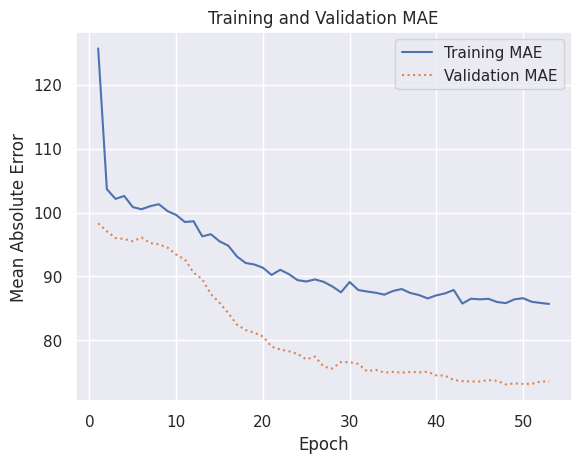

In [36]:
# Set the style of the plots using Seaborn.
sns.set()
# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist_3.history['mae']
val_err = hist_3.history['val_mae']
# Define the number of epochs.
epochs = range(1, len(err) + 1)
# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()
# Use the trained model to predict on the test data.
y_pred_nn_3 = model_3.predict(X_test_scaled)

XGBoost

In [37]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost Regressor
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Set up GridSearchCV
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_xgb_result = grid_xgb.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params_xgb = grid_xgb_result.best_params_
print(f"XGBoost - Best MAE: {-grid_xgb_result.best_score_:.4f}")
print(f"XGBoost - Best parameters: {best_params_xgb}")

# Train the final XGBoost model with the best parameters
best_xgb_model = xgb.XGBRegressor(**best_params_xgb, random_state=42)
best_xgb_model.fit(X_train_scaled, y_train)
best_xgb_model.save_model("model_xgb.json")

# Make predictions on the test set
y_pred_xgb = best_xgb_model.predict(X_test_scaled)

XGBoost - Best MAE: 26.2061
XGBoost - Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


Compare metrics

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the Mean Absolute Error (MAE) between the true and predicted values.
mae_nn_2 = mean_absolute_error(y_test, y_pred_nn_2)
# Calculate the Root Mean Squared Error (RMSE) between the true and predicted values.
mse_nn_2 = mean_squared_error(y_test, y_pred_nn_2)
rmse_nn_2 = np.sqrt(mean_squared_error(y_test, y_pred_nn_2))
# Calculate the R-squared (R2) score, a measure of how well the model explains the variance in the data.
r2_nn_2 = r2_score(y_test, y_pred_nn_2)

print(f"Mean Absolute Error of NN 2: {mae_nn_2}")
print(f"Root Mean Squared Error of NN 2: {rmse_nn_2}")
print(f"R-squared of NN 2: {r2_nn_2}")

Mean Absolute Error of NN 2: 73.705777973794
Root Mean Squared Error of NN 2: 115.11345480874482
R-squared of NN 2: 0.5815273852846246


In [39]:
mae_nn_3 = mean_absolute_error(y_test, y_pred_nn_3)
mse_nn_3 = mean_squared_error(y_test, y_pred_nn_3)
rmse_nn_3 = np.sqrt(mean_squared_error(y_test, y_pred_nn_3))
r2_nn_3 = r2_score(y_test, y_pred_nn_3)

print(f"Mean Absolute Error of NN 3: {mae_nn_3}")
print(f"Root Mean Squared Error of NN 3: {rmse_nn_3}")
print(f"R-squared of NN 3: {r2_nn_3}")

Mean Absolute Error of NN 3: 71.71339337296261
Root Mean Squared Error of NN 3: 119.23287011801678
R-squared of NN 3: 0.5510408134123217


In [40]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb =  mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Mean Absolute Error (XGBoost): {mae_xgb}")
print(f"Root Mean Squared Error (XGBoost): {rmse_xgb}")
print(f"R-squared (XGBoost): {r2_xgb}")

Mean Absolute Error (XGBoost): 23.942769998661483
Root Mean Squared Error (XGBoost): 39.358003809399214
R-squared (XGBoost): 0.9510806145102166



--------------------------------------Comparison of Models---------------------------------------------


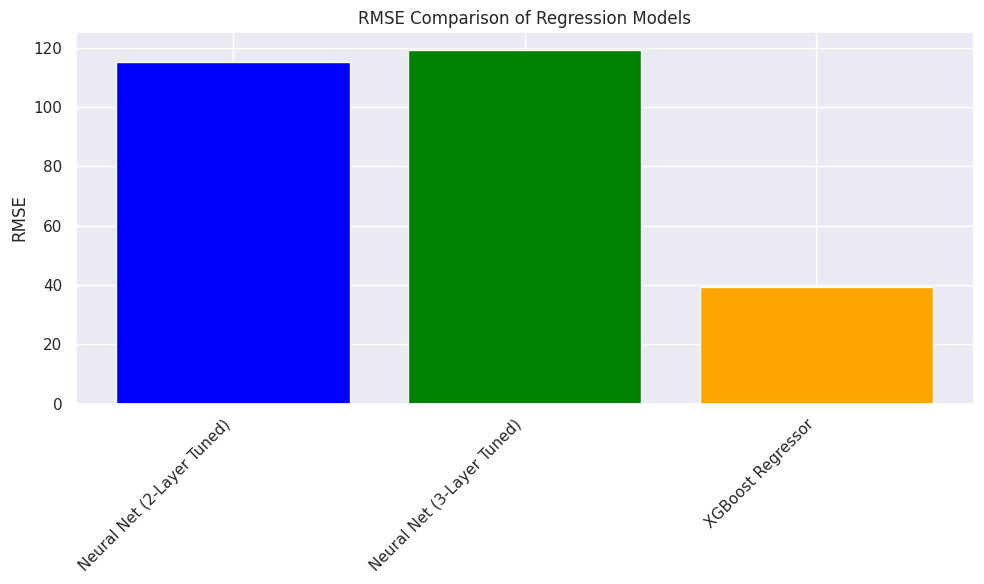

In [41]:
results = pd.DataFrame([
    {'Model': 'Neural Net (2-Layer Tuned)', 'RMSE': rmse_nn_2, 'MAE': mae_nn_2, 'R2': r2_nn_2},
    {'Model': 'Neural Net (3-Layer Tuned)', 'RMSE': rmse_nn_3, 'MAE': mae_nn_3, 'R2': r2_nn_2},
    {'Model': 'XGBoost Regressor', 'RMSE': rmse_xgb, 'MAE': mae_xgb, 'R2': r2_xgb}
])

# Bar chart of RMSE for all models
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['RMSE'], color=['blue', 'green', 'orange', 'red'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Regression Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
# Chiamata a fine script:
invia_notifica_telegram("La rete neurale ha finito! 🚀")